In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from numpy import cos
from math import log
from scipy.interpolate import interp1d
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize_scalar, minimize, fsolve
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import plotly.graph_objects as go
import plotly.express as px
from sympy import symbols, Eq, solve

In [2]:
params = {
    # PM parameters
    'T_prime': 19.9,
    'B_E': 200,
    'p_ME': 0.9,
    'p_ML': 0.25,
    'p_MP': 0.75,
    'tau_E': 1,
    'tau_P': 1,
    'c1': 0.00554,
    'c2': -0.06737,
    'D1': 36.5,
    'b1': 0.04,
    'b2': 0.09,
    'A': -0.03,
    'B': 1.31,
    'C': -4.4,
    'tau_H': 10,
    'DD': 105,
    'Tmin': 14.5,
    'gamma': 1/120, 
    'R_L': 50,
    'N': 8558,
    'M': 1000,
    
    # Initial conditions
    'E_M0': 500,
    'I_H0': 1000,
    'R_H0': 0,
    'I_M0': 0,
}

# Calculate derived initial conditions
params['S_H0'] = params['N'] - params['I_H0']
params['S_M0'] = params['M'] - params['E_M0']

# Initial state vector [S_H, I_H, R_H, S_M, E_M, I_M]
initial_state = np.array([
    params['S_H0'], 
    params['I_H0'], 
    params['R_H0'], 
    params['S_M0'], 
    params['E_M0'], 
    params['I_M0']
])

In [3]:
# ============================================================================
# MODEL FUNCTIONS CLASS
# ============================================================================

class ModelFunctions:
    def __init__(self, params):
        """
        Initialize with parameters dictionary
        """
        self.B_E = params['B_E']
        self.p_ME = params['p_ME']
        self.p_ML = params['p_ML']
        self.p_MP = params['p_MP']
        self.tau_E = params['tau_E']
        self.tau_P = params['tau_P']
        self.c1 = params['c1']
        self.c2 = params['c2']
        self.D1 = params['D1']
        self.b1 = params['b1']
        self.A = params['A']
        self.B = params['B']
        self.C = params['C']
        self.b2 = params['b2']
        self.tau_H = params['tau_H']
        self.DD = params['DD']
        self.Tmin = params['Tmin']
        self.gamma = params['gamma']
        self.R_L = params['R_L']
        self.T_prime = params['T_prime']
        self.N = params['N']
        self.M = params['M']
    
    def tau_L(self, Temp):
        """Temperature-dependent larval duration"""
        denominator = self.c1 * Temp + self.c2
        return np.where(denominator <= 0, 100, 1 / denominator)
    
    def p(self, Temp):
        """Daily survival probability"""
        denominator = self.A * Temp**2 + self.B * Temp + self.C
        return np.where(denominator <= 0, 0, np.exp(-1 / denominator))
    
    def p_LT(self, Temp):
        """Temperature-dependent larval survival"""
        return np.exp(-(self.c1 * Temp + self.c2))
    
    def p_LR(self, Rain):
        """Rainfall-dependent larval survival"""
        Rain_clipped = np.clip(Rain, 0, self.R_L)
        return (4 * self.p_ML / self.R_L**2) * Rain_clipped * (self.R_L - Rain_clipped)
    
    def p_LRT(self, Rain, Temp):
        """Combined rainfall and temperature larval survival"""
        return self.p_LR(Rain) * self.p_LT(Temp)
    
    def p_ER(self, Rain):
        """Rainfall-dependent egg survival"""
        Rain_clipped = np.clip(Rain, 0, self.R_L)
        return (4 * self.p_ME / self.R_L**2) * Rain_clipped * (self.R_L - Rain_clipped)
    
    def p_PR(self, Rain):
        """Rainfall-dependent pupal survival"""
        Rain_clipped = np.clip(Rain, 0, self.R_L)
        return (4 * self.p_MP / self.R_L**2) * Rain_clipped * (self.R_L - Rain_clipped)
    
    def tau_M(self, Temp):
        """Temperature-dependent mosquito maturation time"""
        diff = Temp - self.Tmin
        return np.where(diff <= 0, 1000, self.DD / diff)
    
    def l_tau_M(self, tau_M_val, Temp):
        """Survival through maturation"""
        p_T = self.p(Temp)
        return p_T ** tau_M_val
    
    def mu(self, Temp):
        """Mosquito mortality rate"""
        p_val = self.p(Temp)
        return np.where(p_val <= 0, 1.0, -np.log(p_val))
    
    def a(self, Temp):
        """Temperature-dependent biting rate"""
        return np.maximum(0, (Temp - self.T_prime) / self.D1)
    
    def b(self, Rain, Temp):
        """Birth rate of mosquitoes"""
        tau_L_val = self.tau_L(Temp)
        return (self.B_E * self.p_ER(Rain) * self.p_LRT(Rain, Temp) * self.p_PR(Rain) / 
                (self.tau_E + tau_L_val + self.tau_P))

In [4]:
# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

# Climate parameters for Temp(t) and Rain(t)
T1 = 23.2
T2 = 0.07
omega1 = 0.67
phi1 = 1.53

R1 = 85.9
R2 = 0.98
omega2 = 0.65
phi2 = 1.99

def Temp(t):
       return T1 * (1 + T2 * cos(omega1 * t - phi1))

def Rain(t):
       return R1 * (1 + R2 * cos(omega2 * t - phi2))

def get_current_values(t):
    """Get temperature and precipitation for current time"""
    day_index = int(t)
    T_curr = Temp(day_index)
    R_curr = Rain(day_index)
    return T_curr, R_curr

def create_history_function(initial_state):
    """
    Creates a history function that returns constant initial state for times before t=0
    """
    def history_func(t):
        """
        Returns the state at time t
        For DDEs, this provides values for t < 0
        """
        return initial_state
    
    return history_func

In [5]:
# ============================================================================
# DDE MODEL FUNCTION
# ============================================================================

def dde_model(t, z, history_func, model_funcs):
    """
    DDE function for the model - compatible with ddeint solver
    """
    S_H, I_H, R_H, S_M, E_M, I_M = z
    
    # Get current temperature and precipitation
    T_curr, R_curr = get_current_values(t)
    
    # Calculate current values using model functions
    tau_M_curr = model_funcs.tau_M(T_curr)
    l_curr = model_funcs.l_tau_M(tau_M_curr, T_curr)
    mu_curr = model_funcs.mu(T_curr)
    a_curr = model_funcs.a(T_curr)
    b_curr = model_funcs.b(R_curr, T_curr)
    
    # Get delayed states
    # For t - tau_H (human incubation period)
    S_H_delay, I_H_delay, R_H_delay, S_M_delay, E_M_delay, I_M_delay = history_func(t - model_funcs.tau_H)
    
    # For t - tau_M_curr (mosquito maturation time - temperature dependent)
    S_H_delay_M, I_H_delay_M, R_H_delay_M, S_M_delay_M, E_M_delay_M, I_M_delay_M = history_func(t - tau_M_curr)
    
    # Human equations
    dShdt = -a_curr * model_funcs.b2 * (I_M / model_funcs.N) * S_H
    
    dIhdt = (
        a_curr * model_funcs.b2 * (I_M_delay / model_funcs.N) * S_H_delay
        - model_funcs.gamma * I_H
    )
    
    dRhdt = model_funcs.gamma * I_H
    
    # Mosquito equations
    dSmdt = b_curr - a_curr * model_funcs.b1 * (I_H / model_funcs.N) * S_M - mu_curr * S_M
    
    dEmdt = (
        a_curr * model_funcs.b1 * (I_H / model_funcs.N) * S_M
        - a_curr * model_funcs.b1 * (I_H_delay_M / model_funcs.N) * S_M_delay_M * l_curr
        - mu_curr * E_M
    )
    
    dImdt = (
        a_curr * model_funcs.b1 * (I_H_delay_M / model_funcs.N) * S_M_delay_M * l_curr
        - mu_curr * I_M
    )
    
    return [dShdt, dIhdt, dRhdt, dSmdt, dEmdt, dImdt]

In [6]:
# ============================================================================
# SOLVER WRAPPERS
# ============================================================================

def solve_with_ddeint(t_span, initial_state, model_funcs, step_size=0.1):
    """
    Solve DDE using ddeint solver
    """
    try:
        from ddeint import ddeint
        
        # Create history function
        history_func = create_history_function(initial_state)
        
        # Create wrapper for ddeint
        def model_wrapper(y, t):
            return dde_model(t, y, history_func, model_funcs)
        
        # Solve
        t_eval = np.arange(t_span[0], t_span[1], step_size)
        solution = ddeint(model_wrapper, initial_state, t_eval)
        
        return t_eval, solution.T
        
    except ImportError:
        print("ddeint not installed. Installing...")
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "ddeint"])
        from ddeint import ddeint
        
        # Retry with installed package
        history_func = create_history_function(initial_state)
        
        def model_wrapper(y, t):
            return dde_model(t, y, history_func, model_funcs)
        
        t_eval = np.arange(t_span[0], t_span[1], step_size)
        solution = ddeint(model_wrapper, initial_state, t_eval)

        return t_eval, solution.T

In [7]:
def solve_approximate(t_span, initial_state, model_funcs, step_size=0.1):
    """
    Approximate DDE solution using solve_ivp with stored history
    """
    t_eval = np.arange(t_span[0], t_span[1], step_size)
    dt = t_eval[1] - t_eval[0]
    
    # Store solution history
    solution_history = [initial_state]
    times_history = [t_span[0]]
    
    # Create history lookup function
    def get_history(tau):
        if tau < 0:
            return initial_state
        else:
            # Find nearest stored time
            idx = np.argmin(np.abs(np.array(times_history) - tau))
            if idx < len(solution_history):
                return solution_history[idx]
            else:
                return initial_state
    
    # Solve step by step
    z_current = initial_state
    t_current = t_span[0]
    
    for i, t_next in enumerate(t_eval[1:]):
        # Define ODE function for current step
        def ode_func(t, y):
            return dde_model(t, y, get_history, model_funcs)
        
        # Solve one step
        sol = solve_ivp(
            ode_func,
            (t_current, t_next),
            z_current,
            method='RK45',
            max_step=dt/10,
            rtol=1e-6,
            atol=1e-9
        )
        
        # Update current state
        z_current = sol.y[:, -1]
        t_current = t_next
        
        # Store in history
        solution_history.append(z_current)
        times_history.append(t_current)
    
    return np.array(times_history), np.array(solution_history).T

In [8]:
# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def plot_solution(t, solution, labels=None):
    """
    Plot the solution compartments
    """
    if labels is None:
        labels = ['S_H', 'I_H', 'R_H', 'S_M', 'E_M', 'I_M']
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Human compartments
    for i in range(3):
        axes[0].plot(t, solution[i], label=labels[i], linewidth=2)
    axes[0].set_xlabel('Time (days)')
    axes[0].set_ylabel('Population')
    axes[0].set_title('Human Compartments')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Mosquito compartments
    for i in range(3, 6):
        axes[1].plot(t, solution[i], label=labels[i], linewidth=2)
    axes[1].set_xlabel('Time (days)')
    axes[1].set_ylabel('Population')
    axes[1].set_title('Mosquito Compartments')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

In [9]:
def plot_birth_rate_surface(model_funcs, sim_days=365):
    """
    Create interactive 3D surface plot of birth rate using plotly
    """
    # Compute ranges from Temp and Rain functions
    t_range = np.arange(0, sim_days)
    T_vals = np.array([Temp(t) for t in t_range])
    R_vals = np.array([Rain(t) for t in t_range])
    
    T_min, T_max = T_vals.min(), T_vals.max()
    R_min, R_max = R_vals.min(), R_vals.max()
    
    # Add padding
    T_range = np.linspace(max(0, T_min - 2), T_max + 2, 50)
    R_range = np.linspace(max(0, R_min - 10), min(R_max + 10, model_funcs.R_L), 50)
    
    # Create grid
    T_grid, R_grid = np.meshgrid(T_range, R_range)
    
    # Calculate birth rates (vectorized)
    B_grid = model_funcs.b(R_grid, T_grid)
    
    # Create plotly figure
    fig = go.Figure()
    
    # Surface
    fig.add_trace(go.Surface(
        x=T_grid, y=R_grid, z=B_grid,
        colorscale='Viridis',
        opacity=0.8,
        name='Birth Rate Surface',
        showscale=True,
        colorbar=dict(title='Birth Rate')
    ))
    
    # Actual data points
    B_actual = model_funcs.b(R_vals, T_vals)
    fig.add_trace(go.Scatter3d(
        x=T_vals, y=R_vals, z=B_actual,
        mode='markers',
        marker=dict(size=3, color='red', opacity=0.7),
        name='Daily Values'
    ))
    
    fig.update_layout(
        title='Mosquito Birth Rate as Function of Temperature and Precipitation',
        scene=dict(
            xaxis_title='Temperature (°C)',
            yaxis_title='Precipitation (mm)',
            zaxis_title='Birth Rate'
        ),
        width=900,
        height=700
    )
    
    return fig

Model initialized successfully!
Initial state: [7558 1000    0  500  500    0]

Test at t=0: T=23.27°C, R=51.64mm, b=0.0000

Generating birth rate surface plot...


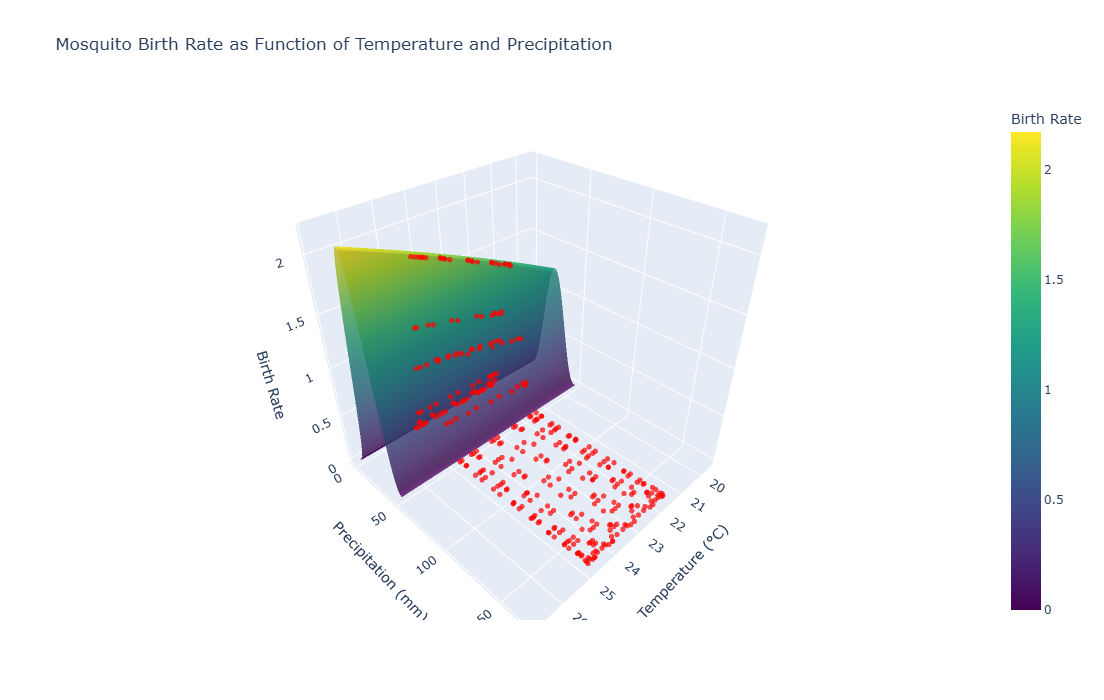


Running DDE simulation...
ddeint failed: 'numpy.ndarray' object is not callable
Using approximate method...
Approximate simulation completed!


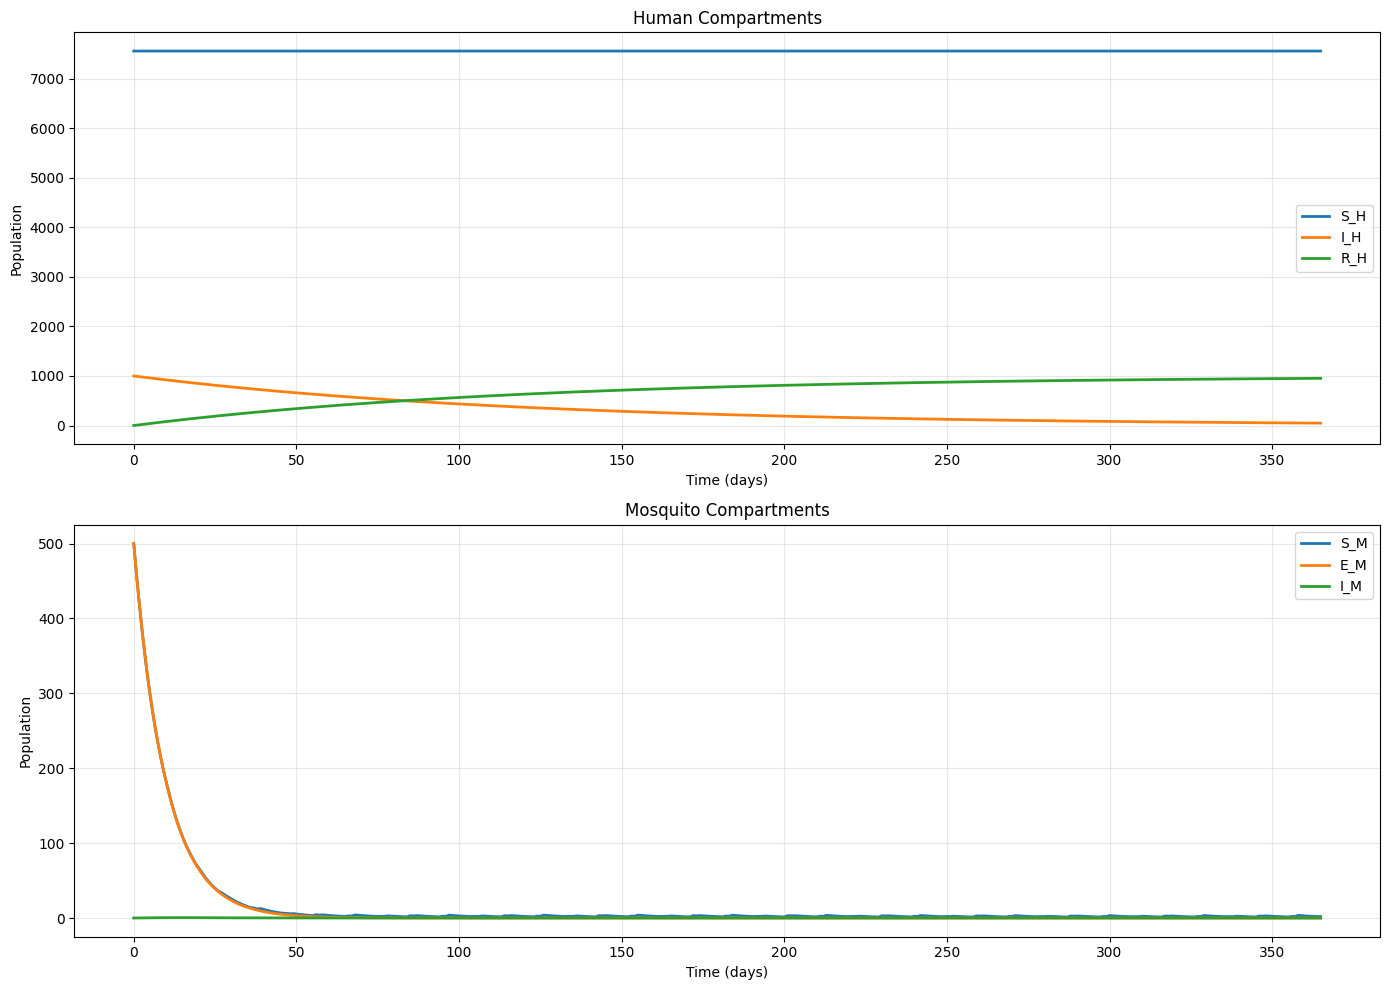

In [10]:
# ============================================================================
# MAIN EXECUTION
# ============================================================================

# Create model functions instance
model_funcs = ModelFunctions(params)

# Create history function
history_func = create_history_function(initial_state)

print("Model initialized successfully!")
print(f"Initial state: {initial_state}")

# Test the birth rate function
T_test, R_test = get_current_values(0)
b_test = model_funcs.b(R_test, T_test)
print(f"\nTest at t=0: T={T_test:.2f}°C, R={R_test:.2f}mm, b={b_test:.4f}")

# Plot birth rate surface
print("\nGenerating birth rate surface plot...")
fig_birth = plot_birth_rate_surface(model_funcs, sim_days=365)
fig_birth.show()

# Uncomment to run the actual DDE simulation
#"""
print("\nRunning DDE simulation...")
SIM_DAYS = 365
STEP_SIZE = 0.1
t_span = (0, SIM_DAYS)

try:
    # Try using ddeint
    t, solution = solve_with_ddeint(t_span, initial_state, model_funcs, STEP_SIZE)
    print("Simulation completed with ddeint!")
except Exception as e:
    print(f"ddeint failed: {e}")
    print("Using approximate method...")
    t, solution = solve_approximate(t_span, initial_state, model_funcs, STEP_SIZE)
    print("Approximate simulation completed!")

# Plot results
fig_sol = plot_solution(t, solution)
plt.show()


Generating time series plots...


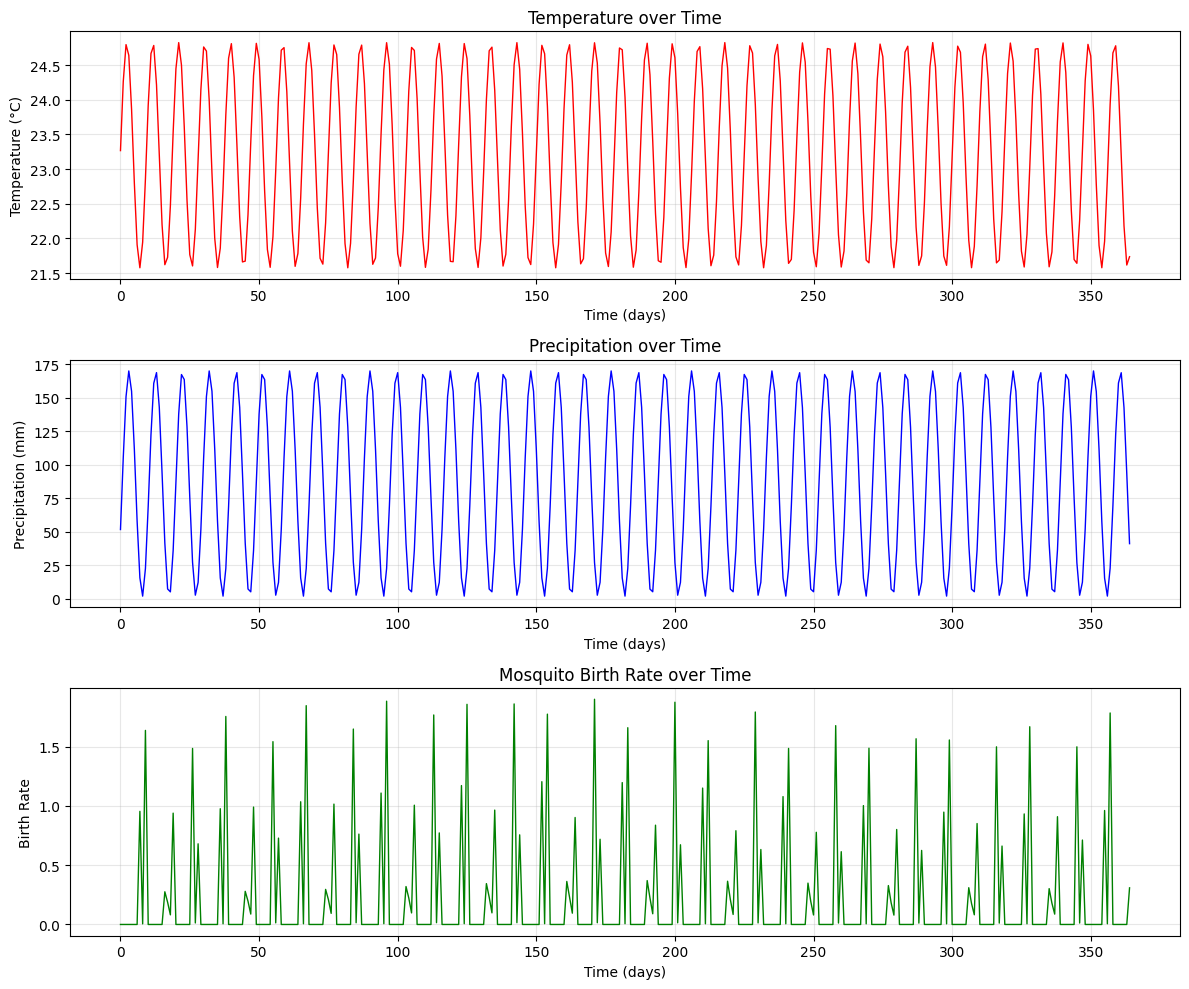

In [11]:
# ============================================================================
# TIME SERIES PLOTS
# ============================================================================

print("\nGenerating time series plots...")

# Time array for plots
t_days = np.arange(0, SIM_DAYS)

# Get temperature and rainfall over time
T_over_time = np.array([Temp(t) for t in t_days])
R_over_time = np.array([Rain(t) for t in t_days])
B_over_time = model_funcs.b(R_over_time, T_over_time)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Temperature over time
axes[0].plot(t_days, T_over_time, 'r-', linewidth=1)
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Temperature over Time')
axes[0].grid(True, alpha=0.3)

# Rainfall over time
axes[1].plot(t_days, R_over_time, 'b-', linewidth=1)
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].set_title('Precipitation over Time')
axes[1].grid(True, alpha=0.3)

# Birth rate over time
axes[2].plot(t_days, B_over_time, 'g-', linewidth=1)
axes[2].set_xlabel('Time (days)')
axes[2].set_ylabel('Birth Rate')
axes[2].set_title('Mosquito Birth Rate over Time')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()